In [1]:
from torchvision.datasets import CIFAR10

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda")

Torch: 2.10.0+cu128
CUDA: 12.8
CUDA Available: True
GPU: Tesla T4


# Load Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

classes = (
    'plane','car','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
)

100%|██████████| 170M/170M [00:02<00:00, 73.4MB/s] 


# Visualize Images

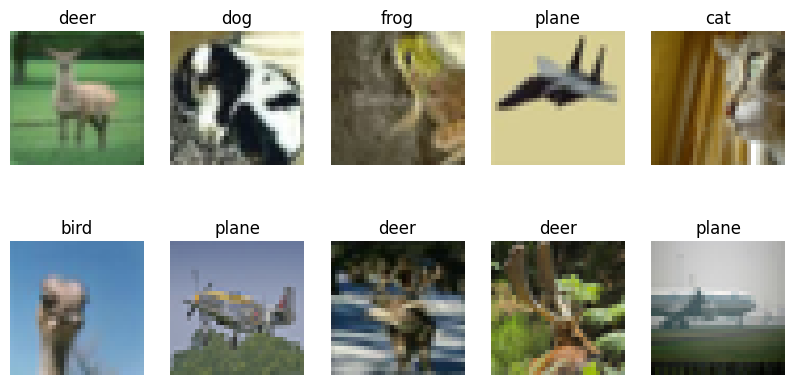

In [4]:
images, labels = next(iter(train_loader))

fig = plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)

    img = images[i] / 2 + 0.5
    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

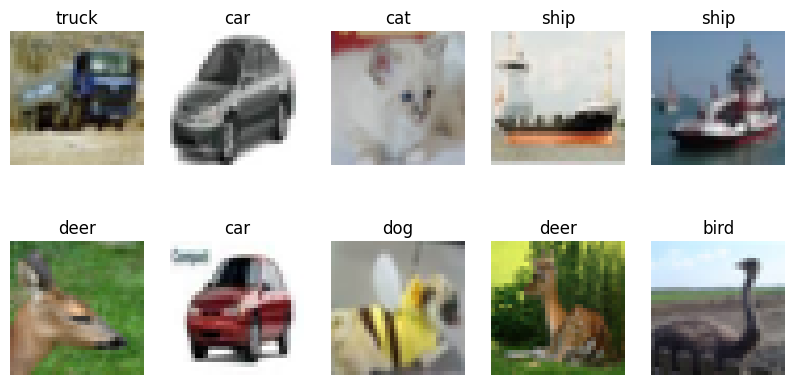

In [5]:
images, labels = next(iter(train_loader))

fig = plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)

    img = images[i] / 2 + 0.5
    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

# ANN Architecture

In [6]:
class ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(3072,512),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self,x):
        return self.network(x)

# Train ANN

In [7]:
ann_model = ANN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    ann_model.parameters(),
    lr=0.001
)

# ANN Training Loop

In [8]:
epochs = 20

ann_train_acc = []

for epoch in range(epochs):

    ann_model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = ann_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    ann_train_acc.append(acc)

    print(
        f"Epoch {epoch+1}: Accuracy={acc:.2f}%"
    )

Epoch 1: Accuracy=40.28%
Epoch 2: Accuracy=46.86%
Epoch 3: Accuracy=50.09%
Epoch 4: Accuracy=52.31%
Epoch 5: Accuracy=54.01%
Epoch 6: Accuracy=55.68%
Epoch 7: Accuracy=57.21%
Epoch 8: Accuracy=58.31%
Epoch 9: Accuracy=59.39%
Epoch 10: Accuracy=60.91%
Epoch 11: Accuracy=61.58%
Epoch 12: Accuracy=62.79%
Epoch 13: Accuracy=63.67%
Epoch 14: Accuracy=64.62%
Epoch 15: Accuracy=65.76%
Epoch 16: Accuracy=66.57%
Epoch 17: Accuracy=67.50%
Epoch 18: Accuracy=68.47%
Epoch 19: Accuracy=69.14%
Epoch 20: Accuracy=69.92%


# ANN Evaluation

In [9]:
ann_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = ann_model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

ann_accuracy = 100 * correct / total

print("ANN Accuracy:", ann_accuracy)

ANN Accuracy: 55.44


# CNN Architecture

In [10]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128*4*4,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                10
            )
        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

# Train CNN

In [11]:
cnn_model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

# CNN Training Loop

In [12]:
epochs = 20

cnn_train_acc = []

for epoch in range(epochs):

    cnn_model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    acc = 100 * correct / total

    cnn_train_acc.append(acc)

    print(
        f"Epoch {epoch+1}: Accuracy={acc:.2f}%"
    )

Epoch 1: Accuracy=51.59%
Epoch 2: Accuracy=66.04%
Epoch 3: Accuracy=70.63%
Epoch 4: Accuracy=73.91%
Epoch 5: Accuracy=76.58%
Epoch 6: Accuracy=78.18%
Epoch 7: Accuracy=80.20%
Epoch 8: Accuracy=82.08%
Epoch 9: Accuracy=83.27%
Epoch 10: Accuracy=84.41%
Epoch 11: Accuracy=85.68%
Epoch 12: Accuracy=86.70%
Epoch 13: Accuracy=88.15%
Epoch 14: Accuracy=88.84%
Epoch 15: Accuracy=90.06%
Epoch 16: Accuracy=90.72%
Epoch 17: Accuracy=91.13%
Epoch 18: Accuracy=92.00%
Epoch 19: Accuracy=92.71%
Epoch 20: Accuracy=93.01%


# CNN Evaluation

In [13]:
cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

cnn_accuracy = 100 * correct / total

print("CNN Accuracy:", cnn_accuracy)

CNN Accuracy: 79.46


# Data Augmentation Experiment

In [14]:
aug_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

In [15]:
train_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=aug_transform
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

In [16]:
aug_cnn_model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    aug_cnn_model.parameters(),
    lr=0.001
)

In [17]:
epochs = 20

aug_train_acc = []

for epoch in range(epochs):

    aug_cnn_model.train()

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader_aug:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = aug_cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    aug_train_acc.append(acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader_aug):.4f} "
        f"Accuracy: {acc:.2f}%"
    )

Epoch [1/20] Loss: 1.5617 Accuracy: 42.48%
Epoch [2/20] Loss: 1.2584 Accuracy: 54.44%
Epoch [3/20] Loss: 1.1358 Accuracy: 59.22%
Epoch [4/20] Loss: 1.0661 Accuracy: 62.13%
Epoch [5/20] Loss: 0.9973 Accuracy: 64.56%
Epoch [6/20] Loss: 0.9569 Accuracy: 66.39%
Epoch [7/20] Loss: 0.9239 Accuracy: 67.47%
Epoch [8/20] Loss: 0.8881 Accuracy: 68.89%
Epoch [9/20] Loss: 0.8569 Accuracy: 70.15%
Epoch [10/20] Loss: 0.8345 Accuracy: 71.01%
Epoch [11/20] Loss: 0.8122 Accuracy: 71.72%
Epoch [12/20] Loss: 0.7898 Accuracy: 72.51%
Epoch [13/20] Loss: 0.7700 Accuracy: 73.00%
Epoch [14/20] Loss: 0.7613 Accuracy: 73.74%
Epoch [15/20] Loss: 0.7432 Accuracy: 74.18%
Epoch [16/20] Loss: 0.7252 Accuracy: 74.98%
Epoch [17/20] Loss: 0.7168 Accuracy: 75.13%
Epoch [18/20] Loss: 0.7046 Accuracy: 75.60%
Epoch [19/20] Loss: 0.6961 Accuracy: 76.06%
Epoch [20/20] Loss: 0.6784 Accuracy: 76.59%


In [18]:
aug_cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = aug_cnn_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

aug_accuracy = 100 * correct / total

print(f"Augmented CNN Accuracy: {aug_accuracy:.2f}%")

Augmented CNN Accuracy: 79.73%


# Comparison Graph

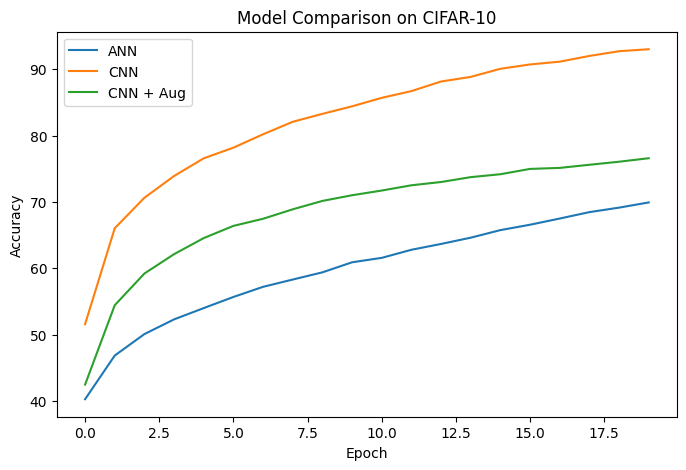

In [19]:
plt.figure(figsize=(8,5))

plt.plot(ann_train_acc, label="ANN")
plt.plot(cnn_train_acc, label="CNN")
plt.plot(aug_train_acc, label="CNN + Aug")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Comparison on CIFAR-10")

plt.legend()
plt.show()

# Final Comparison Table

In [22]:
import pandas as pd
comparison = pd.DataFrame({

    "Model": [
        "ANN",
        "CNN",
        "CNN + Augmentation"
    ],

    "Accuracy": [
        ann_accuracy,
        cnn_accuracy,
        aug_accuracy
    ]
})

comparison

,Model,Accuracy
0,ANN,55.44
1,CNN,79.46
2,CNN + Augmentation,79.73
